In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn --quiet

In [5]:
from pathlib import Path
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from datasets import Dataset
    USE_DATASETS = True
except ImportError:
    USE_DATASETS = False

PROJECT_ROOT = Path("/workspace/SemDrug")

SEMDRUG_JSON = PROJECT_ROOT / "data" / "drugbank_semantic_mmr_d4_pool64_k10_mmr0.5_delta0.05_coldtop1sim0.9.json"
KPATHS_JSON = PROJECT_ROOT / "prompt" / "drugbank" / "drugbank_K-paths_d4_pool64_k10_mmr0.5_delta0.05_coldtop1sim0.9.json"

# From your sample: label_idx 84 corresponds to relation id 107.
# Therefore relation_id = label_idx + 23.
DRUGBANK_RELATION_OFFSET = 0

print("SemDrug:", SEMDRUG_JSON)
print("K-Paths:", KPATHS_JSON)

SemDrug: /workspace/SemDrug/data/drugbank_semantic_mmr_d4_pool64_k10_mmr0.5_delta0.05_coldtop1sim0.9.json
K-Paths: /workspace/SemDrug/prompt/drugbank/drugbank_K-paths_d4_pool64_k10_mmr0.5_delta0.05_coldtop1sim0.9.json


In [6]:
def load_json_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    if USE_DATASETS:
        try:
            return Dataset.from_json(str(path)).to_pandas()
        except Exception as e:
            print("Dataset.from_json failed, fallback to pandas:", e)

    try:
        return pd.read_json(path, lines=True)
    except ValueError:
        return pd.read_json(path)


sem = load_json_table(SEMDRUG_JSON)
kp = load_json_table(KPATHS_JSON)

print("SemDrug rows:", len(sem))
print("K-Paths rows:", len(kp))

print("\nSemDrug columns:")
print(sem.columns.tolist())

print("\nK-Paths columns:")
print(kp.columns.tolist())

display(sem.head(2))
display(kp.head(2))

SemDrug rows: 31984
K-Paths rows: 31984

SemDrug columns:
['Y', 'drug1_name', 'drug2_name', 'drug1_desc', 'drug2_desc', 'drug1_db', 'drug2_db', 'drug1_id', 'drug2_id', 'label_idx', 'label', 'drug_pair', 'all_paths', 'path_str', 'raw_path_count', 'path_count', 'retrieval_source', 'complete_evidence', 'coverage_diag', 'candidate_count', 'used_leakage_safety_recovery']

K-Paths columns:
['Y', 'drug1_name', 'drug2_name', 'drug1_desc', 'drug2_desc', 'drug1_db', 'drug2_db', 'drug1_id', 'drug2_id', 'label_idx', 'label', 'drug_pair', 'all_paths', 'path_str', 'raw_path_count', 'path_count', 'retrieval_source', 'complete_evidence', 'coverage_diag', 'candidate_count', 'used_leakage_safety_recovery']


,Y,drug1_name,drug2_name,drug1_desc,drug2_desc,drug1_db,drug2_db,drug1_id,drug2_id,label_idx,...,drug_pair,all_paths,path_str,raw_path_count,path_count,retrieval_source,complete_evidence,coverage_diag,candidate_count,used_leakage_safety_recovery
0,1,Glycopyrronium,Cyclopentolate,"Glycopyrronium, also known as NVA237 or glycop...",A parasympatholytic anticholinergic used solel...,DB00986,DB00979,28,74,1,...,"('DB00986', 'DB00979')","[[[28, 24, 14], [14, 155, 74]], [[28, 71, 465]...",Glycopyrronium may increase the anticholinergi...,10,10,semantic_mmr_reranked_paths,True,"{'d1_degree': 424, 'd1_in_graph': True, 'd1_in...",64,False
1,1,Aclidinium,Pirenzepine,Aclidinium is an anticholinergic for the long-...,An antimuscarinic agent that inhibits gastric ...,DB08897,DB00670,12,15,1,...,"('DB08897', 'DB00670')","[[[12, 24, 69], [69, 155, 1386], [1386, 155, 1...",Aclidinium may increase the anticholinergic ac...,10,10,semantic_mmr_reranked_paths,True,"{'d1_degree': 236, 'd1_in_graph': True, 'd1_in...",64,False


,Y,drug1_name,drug2_name,drug1_desc,drug2_desc,drug1_db,drug2_db,drug1_id,drug2_id,label_idx,...,drug_pair,all_paths,path_str,raw_path_count,path_count,retrieval_source,complete_evidence,coverage_diag,candidate_count,used_leakage_safety_recovery
0,1,Glycopyrronium,Cyclopentolate,"Glycopyrronium, also known as NVA237 or glycop...",A parasympatholytic anticholinergic used solel...,DB00986,DB00979,28,74,1,...,"('DB00986', 'DB00979')","[[[28, 24, 14], [14, 155, 74]], [[28, 155, 168...",Glycopyrronium may increase the anticholinergi...,10,10,kpaths,True,"{'d1_degree': 424, 'd1_in_graph': True, 'd1_in...",0,False
1,1,Aclidinium,Pirenzepine,Aclidinium is an anticholinergic for the long-...,An antimuscarinic agent that inhibits gastric ...,DB08897,DB00670,12,15,1,...,"('DB08897', 'DB00670')","[[[12, 6, 15399], [15399, 160, 15]], [[12, 6, ...",Aclidinium (Compound) binds CHRM5 (Gene) and C...,10,10,kpaths,True,"{'d1_degree': 236, 'd1_in_graph': True, 'd1_in...",0,False


In [7]:
def parse_paths(x):
    if isinstance(x, list):
        return x

    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            return json.loads(x)
        except Exception:
            pass
        try:
            return ast.literal_eval(x)
        except Exception:
            return []

    return []


def parse_coverage_diag(x):
    if isinstance(x, dict):
        return x

    if x is None or (isinstance(x, float) and np.isnan(x)):
        return {}

    if isinstance(x, str):
        x = x.strip()
        if not x:
            return {}
        try:
            return json.loads(x)
        except Exception:
            pass
        try:
            return ast.literal_eval(x)
        except Exception:
            return {}

    return {}


def safe_bool(x, default=False):
    if pd.isna(x):
        return default
    if isinstance(x, bool):
        return x
    if isinstance(x, (int, np.integer)):
        return bool(x)
    if isinstance(x, (float, np.floating)):
        return bool(int(x))
    if isinstance(x, str):
        x = x.strip().lower()
        if x in {"true", "1", "yes", "y"}:
            return True
        if x in {"false", "0", "no", "n"}:
            return False
    return default


def path_signature(path):
    return tuple(tuple(int(z) for z in triple) for triple in path)


def get_relation_ids(paths):
    rels = []
    for path in paths:
        for triple in path:
            if len(triple) >= 3:
                rels.append(int(triple[1]))
    return rels


def has_direct_leak(paths, drug1_id, drug2_id, target_rel_id):
    """
    Direct leakage check:
    path exactly contains direct edge drug1 --gold_rel--> drug2.
    This should ideally always be False.
    """
    drug1_id = int(drug1_id)
    drug2_id = int(drug2_id)
    target_rel_id = int(target_rel_id)

    for path in paths:
        if len(path) == 1:
            u, r, v = map(int, path[0])
            if u == drug1_id and r == target_rel_id and v == drug2_id:
                return True

    return False


def retrieval_features(df, mode_name):
    rows = []

    for idx, row in df.iterrows():
        paths = parse_paths(row.get("all_paths", []))
        path_sigs = [path_signature(p) for p in paths]
        rel_ids = get_relation_ids(paths)

        drug1_id = int(row["drug1_id"])
        drug2_id = int(row["drug2_id"])
        label_idx = int(row["label_idx"])
        target_rel_id = label_idx + DRUGBANK_RELATION_OFFSET

        path_lens = [len(p) for p in paths]

        coverage = parse_coverage_diag(row.get("coverage_diag", {}))

        target_rel_count = sum(r == target_rel_id for r in rel_ids)
        target_rel_path_count = 0
        first_edge_target_count = 0
        last_edge_target_count = 0

        for p in paths:
            if any(int(t[1]) == target_rel_id for t in p):
                target_rel_path_count += 1

            if len(p) > 0 and int(p[0][1]) == target_rel_id:
                first_edge_target_count += 1

            if len(p) > 0 and int(p[-1][1]) == target_rel_id:
                last_edge_target_count += 1

        path_str = row.get("path_str", "")
        if not isinstance(path_str, str):
            path_str = str(path_str)

        rows.append({
            "row_idx": idx,
            "mode": mode_name,

            "drug1_id": drug1_id,
            "drug2_id": drug2_id,
            "drug1_name": row.get("drug1_name", ""),
            "drug2_name": row.get("drug2_name", ""),
            "label_idx": label_idx,
            "target_rel_id": target_rel_id,

            "path_count_col": row.get("path_count", np.nan),
            "raw_path_count": row.get("raw_path_count", np.nan),
            "candidate_count": row.get("candidate_count", np.nan),
            "complete_evidence": row.get("complete_evidence", np.nan),
            "retrieval_source": row.get("retrieval_source", ""),
            "used_leakage_safety_recovery": row.get("used_leakage_safety_recovery", False),

            "num_paths": len(paths),
            "avg_path_len": np.mean(path_lens) if path_lens else 0,
            "min_path_len": np.min(path_lens) if path_lens else 0,
            "max_path_len": np.max(path_lens) if path_lens else 0,

            "num_unique_paths": len(set(path_sigs)),
            "num_unique_relations": len(set(rel_ids)),
            "target_relation_edge_count": target_rel_count,
            "target_relation_path_count": target_rel_path_count,
            "has_target_relation_path": target_rel_path_count > 0,
            "first_edge_target_count": first_edge_target_count,
            "last_edge_target_count": last_edge_target_count,

            "has_direct_leak": has_direct_leak(
                paths, drug1_id, drug2_id, target_rel_id
            ),

            "path_str_chars": len(path_str),
            "path_str_lines": path_str.count("\n") + 1 if path_str else 0,

            "d1_degree": coverage.get("d1_degree", np.nan),
            "d2_degree": coverage.get("d2_degree", np.nan),
            "d1_in_graph": coverage.get("d1_in_graph", np.nan),
            "d2_in_graph": coverage.get("d2_in_graph", np.nan),
            "d1_in_original_kg": coverage.get("d1_in_original_kg", np.nan),
            "d2_in_original_kg": coverage.get("d2_in_original_kg", np.nan),
            "d1_was_cold_start": coverage.get("d1_was_cold_start", False),
            "d2_was_cold_start": coverage.get("d2_was_cold_start", False),

            "path_signatures": set(path_sigs),
        })

    out = pd.DataFrame(rows)
    out["has_cold_start_endpoint"] = (
        out["d1_was_cold_start"].apply(lambda x: safe_bool(x, False))
        | out["d2_was_cold_start"].apply(lambda x: safe_bool(x, False))
    )

    return out


sem_feat = retrieval_features(sem, "SemDrug")
kp_feat = retrieval_features(kp, "KPathsProxy")

print("Sem features:", sem_feat.shape)
print("KPaths features:", kp_feat.shape)

display(sem_feat.head())
display(kp_feat.head())

Sem features: (31984, 38)
KPaths features: (31984, 38)


,row_idx,mode,drug1_id,drug2_id,drug1_name,drug2_name,label_idx,target_rel_id,path_count_col,raw_path_count,...,d1_degree,d2_degree,d1_in_graph,d2_in_graph,d1_in_original_kg,d2_in_original_kg,d1_was_cold_start,d2_was_cold_start,path_signatures,has_cold_start_endpoint
0,0,SemDrug,28,74,Glycopyrronium,Cyclopentolate,1,1,10,10,...,424,126,True,True,True,True,False,False,"{((28, 21, 28467), (28467, 175, 74)), ((28, 24...",False
1,1,SemDrug,12,15,Aclidinium,Pirenzepine,1,1,10,10,...,236,36,True,True,True,True,False,False,"{((12, 24, 76), (76, 69, 681), (681, 155, 15))...",False
2,2,SemDrug,20,15,Umeclidinium,Pirenzepine,1,1,10,10,...,218,36,True,True,True,True,False,False,"{((20, 69, 681), (681, 155, 15)), ((20, 69, 49...",False
3,3,SemDrug,20,68,Umeclidinium,Pipecuronium,1,1,10,10,...,218,20,True,True,True,True,False,False,"{((20, 24, 28), (28, 6, 5535), (5535, 160, 68)...",False
4,4,SemDrug,15,16,Pirenzepine,Mianserin,1,1,10,10,...,36,598,True,True,True,True,False,False,"{((15, 1, 270), (270, 192, 543), (543, 1, 16))...",False


,row_idx,mode,drug1_id,drug2_id,drug1_name,drug2_name,label_idx,target_rel_id,path_count_col,raw_path_count,...,d1_degree,d2_degree,d1_in_graph,d2_in_graph,d1_in_original_kg,d2_in_original_kg,d1_was_cold_start,d2_was_cold_start,path_signatures,has_cold_start_endpoint
0,0,KPathsProxy,28,74,Glycopyrronium,Cyclopentolate,1,1,10,10,...,424,126,True,True,True,True,False,False,"{((28, 24, 14), (14, 155, 74)), ((28, 24, 14),...",False
1,1,KPathsProxy,12,15,Aclidinium,Pirenzepine,1,1,10,10,...,236,36,True,True,True,True,False,False,"{((12, 24, 69), (69, 1, 270), (270, 155, 15)),...",False
2,2,KPathsProxy,20,15,Umeclidinium,Pirenzepine,1,1,10,10,...,218,36,True,True,True,True,False,False,"{((20, 69, 681), (681, 155, 16883), (16883, 15...",False
3,3,KPathsProxy,20,68,Umeclidinium,Pipecuronium,1,1,10,10,...,218,20,True,True,True,True,False,False,"{((20, 24, 28), (28, 6, 12835), (12835, 160, 6...",False
4,4,KPathsProxy,15,16,Pirenzepine,Mianserin,1,1,10,10,...,36,598,True,True,True,True,False,False,"{((15, 1, 543), (543, 1, 353), (353, 1, 16)), ...",False


In [8]:
summary_cols = [
    "num_paths",
    "raw_path_count",
    "candidate_count",
    "avg_path_len",
    "min_path_len",
    "max_path_len",
    "num_unique_paths",
    "num_unique_relations",
    "target_relation_edge_count",
    "target_relation_path_count",
    "has_target_relation_path",
    "first_edge_target_count",
    "last_edge_target_count",
    "has_direct_leak",
    "path_str_chars",
    "path_str_lines",
    "has_cold_start_endpoint",
]

combined_feat = pd.concat([sem_feat, kp_feat], ignore_index=True)

summary = (
    combined_feat
    .groupby("mode")[summary_cols]
    .agg(["mean", "median", "min", "max"])
)

display(summary)

num_paths                raw_path_count                 \
                 mean median min max           mean median min max   
mode                                                                 
KPathsProxy  9.963763   10.0   1  10       9.963763   10.0   1  10   
SemDrug      9.979115   10.0   1  10       9.979115   10.0   1  10   

            candidate_count         ... path_str_chars       path_str_lines  \
                       mean median  ...            min   max           mean   
mode                                ...                                       
KPathsProxy        0.000000    0.0  ...            286  3322       9.963763   
SemDrug           63.645979   64.0  ...            286  3333       9.979115   

                           has_cold_start_endpoint                      
            median min max                    mean median    min   max  
mode                                                                    
KPathsProxy   10.0   1  10                0.124656    0.0  False  True  
SemDrug       10.0   1  10                0.124656    0.0  False  True  

[2 rows x 68 columns]

In [10]:
key_cols = ["drug1_id", "drug2_id", "label_idx"]

sem_small = sem_feat.drop(columns=["path_signatures"]).copy()
kp_small = kp_feat.drop(columns=["path_signatures"]).copy()

merged = sem_small.merge(
    kp_small,
    on=key_cols,
    suffixes=("_sem", "_kp"),
    how="inner",
)

print("Merged rows:", len(merged))
print("Sem rows:", len(sem_feat))
print("KPaths rows:", len(kp_feat))

if len(merged) != len(sem_feat) or len(merged) != len(kp_feat):
    print("Warning: row alignment is not perfect. Check dataset order/keys.")

display(merged.head())

Merged rows: 31984
Sem rows: 31984
KPaths rows: 31984


,row_idx_sem,mode_sem,drug1_id,drug2_id,drug1_name_sem,drug2_name_sem,label_idx,target_rel_id_sem,path_count_col_sem,raw_path_count_sem,...,path_str_lines_kp,d1_degree_kp,d2_degree_kp,d1_in_graph_kp,d2_in_graph_kp,d1_in_original_kg_kp,d2_in_original_kg_kp,d1_was_cold_start_kp,d2_was_cold_start_kp,has_cold_start_endpoint_kp
0,0,SemDrug,28,74,Glycopyrronium,Cyclopentolate,1,1,10,10,...,10,424,126,True,True,True,True,False,False,False
1,1,SemDrug,12,15,Aclidinium,Pirenzepine,1,1,10,10,...,10,236,36,True,True,True,True,False,False,False
2,2,SemDrug,20,15,Umeclidinium,Pirenzepine,1,1,10,10,...,10,218,36,True,True,True,True,False,False,False
3,3,SemDrug,20,68,Umeclidinium,Pipecuronium,1,1,10,10,...,10,218,20,True,True,True,True,False,False,False
4,4,SemDrug,15,16,Pirenzepine,Mianserin,1,1,10,10,...,10,36,598,True,True,True,True,False,False,False


Path overlap summary:


count    31984.000000
mean         0.192353
std          0.122408
min          0.000000
10%          0.052632
25%          0.111111
50%          0.176471
75%          0.250000
90%          0.333333
max          1.000000
Name: path_jaccard, dtype: float64

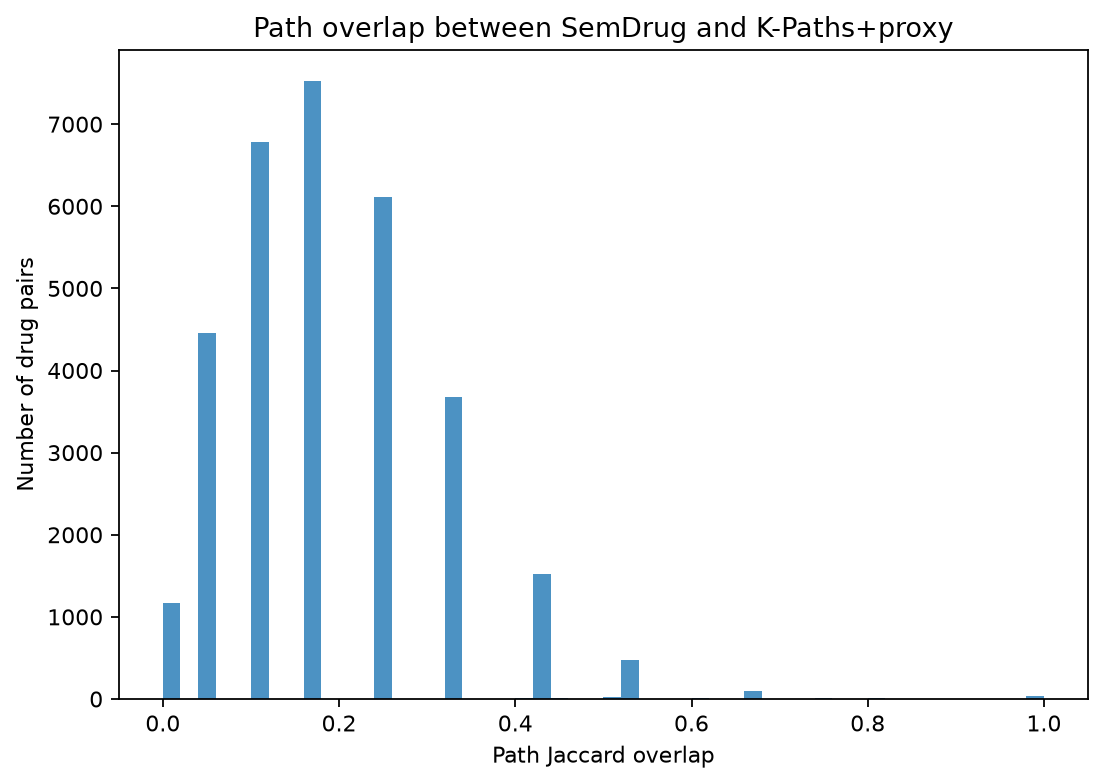

In [11]:
sem_sig_map = {
    (r.drug1_id, r.drug2_id, r.label_idx): r.path_signatures
    for r in sem_feat.itertuples()
}

kp_sig_map = {
    (r.drug1_id, r.drug2_id, r.label_idx): r.path_signatures
    for r in kp_feat.itertuples()
}

rows = []

for key in set(sem_sig_map) & set(kp_sig_map):
    a = sem_sig_map[key]
    b = kp_sig_map[key]

    inter = len(a & b)
    union = len(a | b)

    rows.append({
        "drug1_id": key[0],
        "drug2_id": key[1],
        "label_idx": key[2],
        "path_overlap_count": inter,
        "path_union_count": union,
        "path_jaccard": inter / union if union else 0,
        "sem_num_unique_paths": len(a),
        "kp_num_unique_paths": len(b),
    })

overlap_df = pd.DataFrame(rows)

merged = merged.merge(
    overlap_df,
    on=key_cols,
    how="left",
)

print("Path overlap summary:")
display(overlap_df["path_jaccard"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

plt.figure(figsize=(7, 5), dpi=160)
plt.hist(overlap_df["path_jaccard"], bins=50, alpha=0.8)
plt.title("Path overlap between SemDrug and K-Paths+proxy")
plt.xlabel("Path Jaccard overlap")
plt.ylabel("Number of drug pairs")
plt.tight_layout()
plt.show()

In [16]:
def relation_sequence_signature(path):
    return tuple(int(triple[1]) for triple in path)


def relation_id_set(paths):
    rels = set()
    for path in paths:
        for triple in path:
            rels.add(int(triple[1]))
    return rels


def relation_sequence_set(paths):
    return set(relation_sequence_signature(p) for p in paths)


def jaccard(a, b):
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


sem_rel_map = {}
kp_rel_map = {}
sem_relseq_map = {}
kp_relseq_map = {}

for _, row in sem.iterrows():
    key = (int(row["drug1_id"]), int(row["drug2_id"]), int(row["label_idx"]))
    paths = parse_paths(row.get("all_paths", []))
    sem_rel_map[key] = relation_id_set(paths)
    sem_relseq_map[key] = relation_sequence_set(paths)

for _, row in kp.iterrows():
    key = (int(row["drug1_id"]), int(row["drug2_id"]), int(row["label_idx"]))
    paths = parse_paths(row.get("all_paths", []))
    kp_rel_map[key] = relation_id_set(paths)
    kp_relseq_map[key] = relation_sequence_set(paths)

rows = []

for key in set(sem_rel_map) & set(kp_rel_map):
    rows.append({
        "drug1_id": key[0],
        "drug2_id": key[1],
        "label_idx": key[2],
        "relation_id_jaccard": jaccard(sem_rel_map[key], kp_rel_map[key]),
        "relation_sequence_jaccard": jaccard(sem_relseq_map[key], kp_relseq_map[key]),
        "sem_num_relation_ids": len(sem_rel_map[key]),
        "kp_num_relation_ids": len(kp_rel_map[key]),
        "sem_num_relation_sequences": len(sem_relseq_map[key]),
        "kp_num_relation_sequences": len(kp_relseq_map[key]),
    })

rel_overlap_df = pd.DataFrame(rows)

print("Relation ID Jaccard:")
display(rel_overlap_df["relation_id_jaccard"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

print("\nRelation sequence Jaccard:")
display(rel_overlap_df["relation_sequence_jaccard"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

display(rel_overlap_df.head())

Relation ID Jaccard:


count    31984.000000
mean         0.697405
std          0.203633
min          0.125000
10%          0.400000
25%          0.545455
50%          0.714286
75%          0.857143
90%          1.000000
max          1.000000
Name: relation_id_jaccard, dtype: float64


Relation sequence Jaccard:


count    31984.000000
mean         0.516846
std          0.220436
min          0.052632
10%          0.200000
25%          0.333333
50%          0.500000
75%          0.666667
90%          0.818182
max          1.000000
Name: relation_sequence_jaccard, dtype: float64

,drug1_id,drug2_id,label_idx,relation_id_jaccard,relation_sequence_jaccard,sem_num_relation_ids,kp_num_relation_ids,sem_num_relation_sequences,kp_num_relation_sequences
0,617,1034,48,1.000000,1.000000,17,17,10,10
1,332,1114,72,0.583333,0.266667,10,9,9,10
2,617,772,48,0.600000,0.428571,12,12,10,10
3,1072,1036,59,0.750000,0.428571,10,11,10,10
4,417,666,19,0.666667,0.428571,14,11,10,10


Relation ID Jaccard:


count    31984.000000
mean         0.697405
std          0.203633
min          0.125000
10%          0.400000
25%          0.545455
50%          0.714286
75%          0.857143
90%          1.000000
max          1.000000
Name: relation_id_jaccard, dtype: float64


Relation sequence Jaccard:


count    31984.000000
mean         0.516846
std          0.220436
min          0.052632
10%          0.200000
25%          0.333333
50%          0.500000
75%          0.666667
90%          0.818182
max          1.000000
Name: relation_sequence_jaccard, dtype: float64

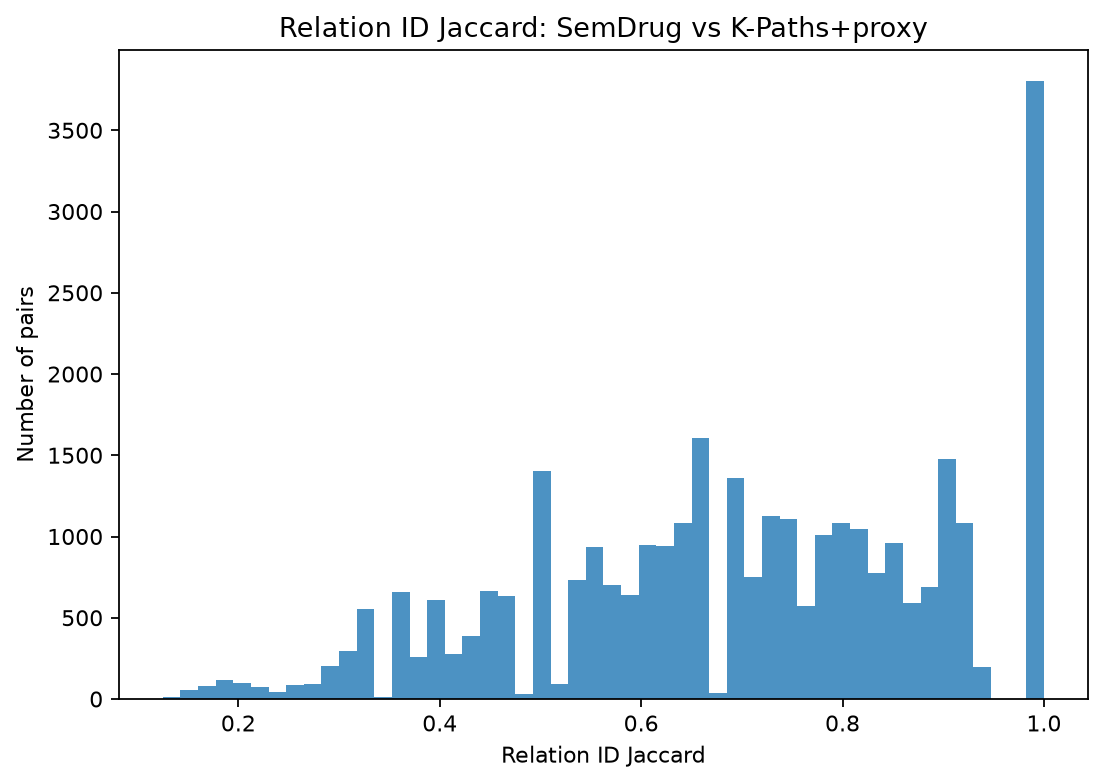

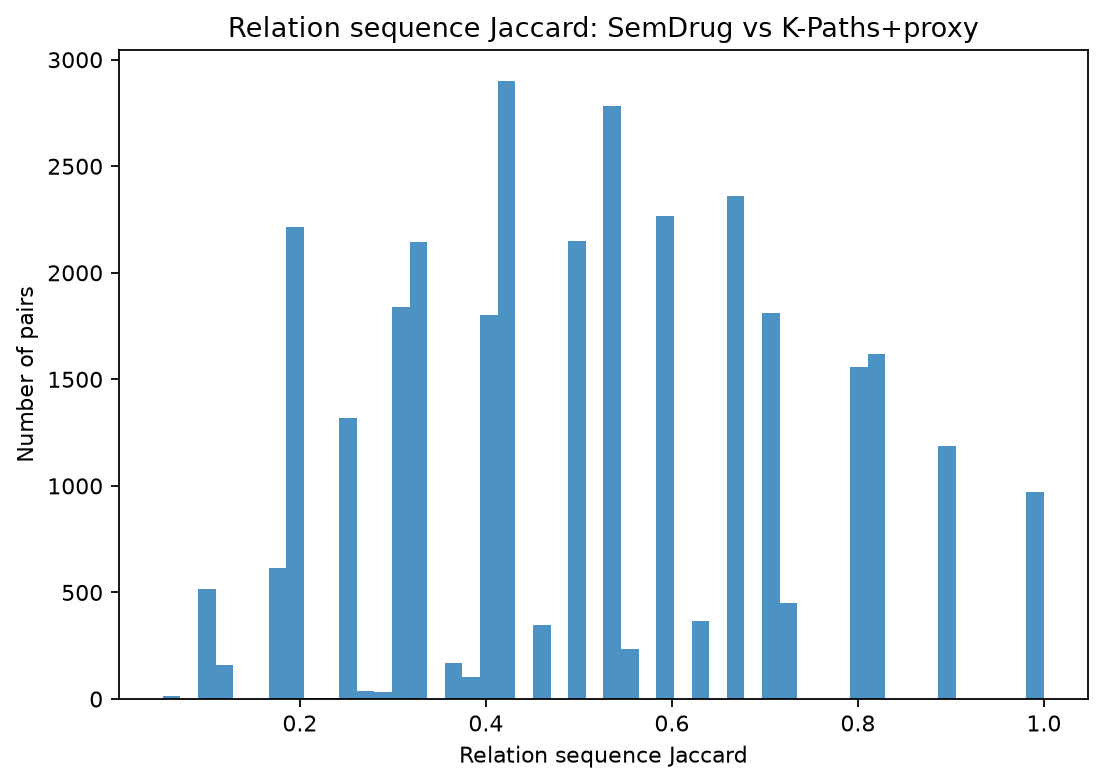

In [17]:
print("Relation ID Jaccard:")
display(rel_overlap_df["relation_id_jaccard"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

print("\nRelation sequence Jaccard:")
display(rel_overlap_df["relation_sequence_jaccard"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

plt.figure(figsize=(7, 5), dpi=160)
plt.hist(rel_overlap_df["relation_id_jaccard"], bins=50, alpha=0.8)
plt.title("Relation ID Jaccard: SemDrug vs K-Paths+proxy")
plt.xlabel("Relation ID Jaccard")
plt.ylabel("Number of pairs")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5), dpi=160)
plt.hist(rel_overlap_df["relation_sequence_jaccard"], bins=50, alpha=0.8)
plt.title("Relation sequence Jaccard: SemDrug vs K-Paths+proxy")
plt.xlabel("Relation sequence Jaccard")
plt.ylabel("Number of pairs")
plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path
import os
import json
import pickle
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/workspace/SemDrug")

EMB_PATH = PROJECT_ROOT / "embeddings" / "drugbank_node_embeddings_full.pkl"
NODE2ID_PATH = PROJECT_ROOT / "data" / "drugbank" / "node2id.json"

RETRIEVAL_PATH = (
    PROJECT_ROOT
    / "prompt"
    / "drugbank"
    / "drugbank_semantic_mmr_d4_pool64_k10_mmr0.5_delta0.05_coldtop1sim0.9.json"
)

print("Embedding path:", EMB_PATH)
print("Exists:", EMB_PATH.exists())
print("Size MB:", EMB_PATH.stat().st_size / 1024 / 1024)

with open(EMB_PATH, "rb") as f:
    emb_dict_raw = pickle.load(f)

emb_dict = {}
for k, v in emb_dict_raw.items():
    try:
        k = int(k)
    except Exception:
        pass
    emb_dict[k] = np.asarray(v, dtype=np.float32)

print("Number of embedding nodes:", len(emb_dict))

dims = [v.shape for v in emb_dict.values()]
print("Unique embedding shapes:", pd.Series(dims).value_counts().head(10))

X = np.vstack(list(emb_dict.values()))
print("Embedding matrix:", X.shape)

print("NaN count:", np.isnan(X).sum())
print("Inf count:", np.isinf(X).sum())

norms = np.linalg.norm(X, axis=1)
print("\nNorm distribution:")
print(pd.Series(norms).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

print("Zero/near-zero vectors:", int((norms < 1e-8).sum()))

Embedding path: /workspace/SemDrug/embeddings/drugbank_node_embeddings_full.pkl
Exists: True
Size MB: 101.19000244140625
Number of embedding nodes: 34124
Unique embedding shapes: (768,)    34124
Name: count, dtype: int64
Embedding matrix: (34124, 768)
NaN count: 0
Inf count: 0

Norm distribution:
count    3.412400e+04
mean     1.000000e+00
std      4.710664e-08
min      9.999998e-01
1%       9.999999e-01
5%       9.999999e-01
50%      1.000000e+00
95%      1.000000e+00
99%      1.000000e+00
max      1.000000e+00
dtype: float64
Zero/near-zero vectors: 0
